
=== 2-way ANOVA + age covariate ===
                               sum_sq   df            F        PR(>F)
C(occupation)            1.536417e+11  4.0  7752.279487  0.000000e+00
C(gender)                8.881285e+08  1.0   179.248704  9.975851e-40
C(occupation):C(gender)  1.231663e+09  4.0    62.145863  1.729679e-50

Shapiro–Wilk test: W = 0.988,  p = 2.545e-15


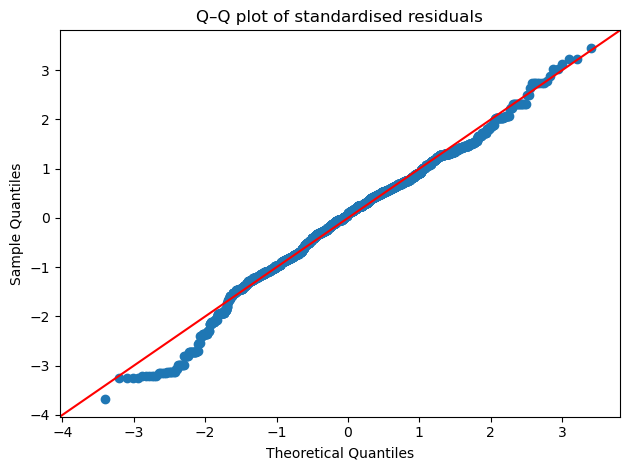

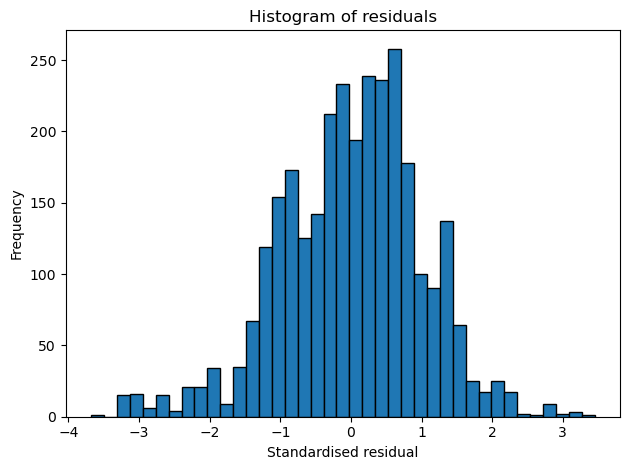

/var/folders/xf/3h6xnmdj0jg__mms2zt6r6wc0000gn/T/ipykernel_3809/1682704000.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_tbl = (df.groupby(["occupation", "gender"])["middle_salary"]


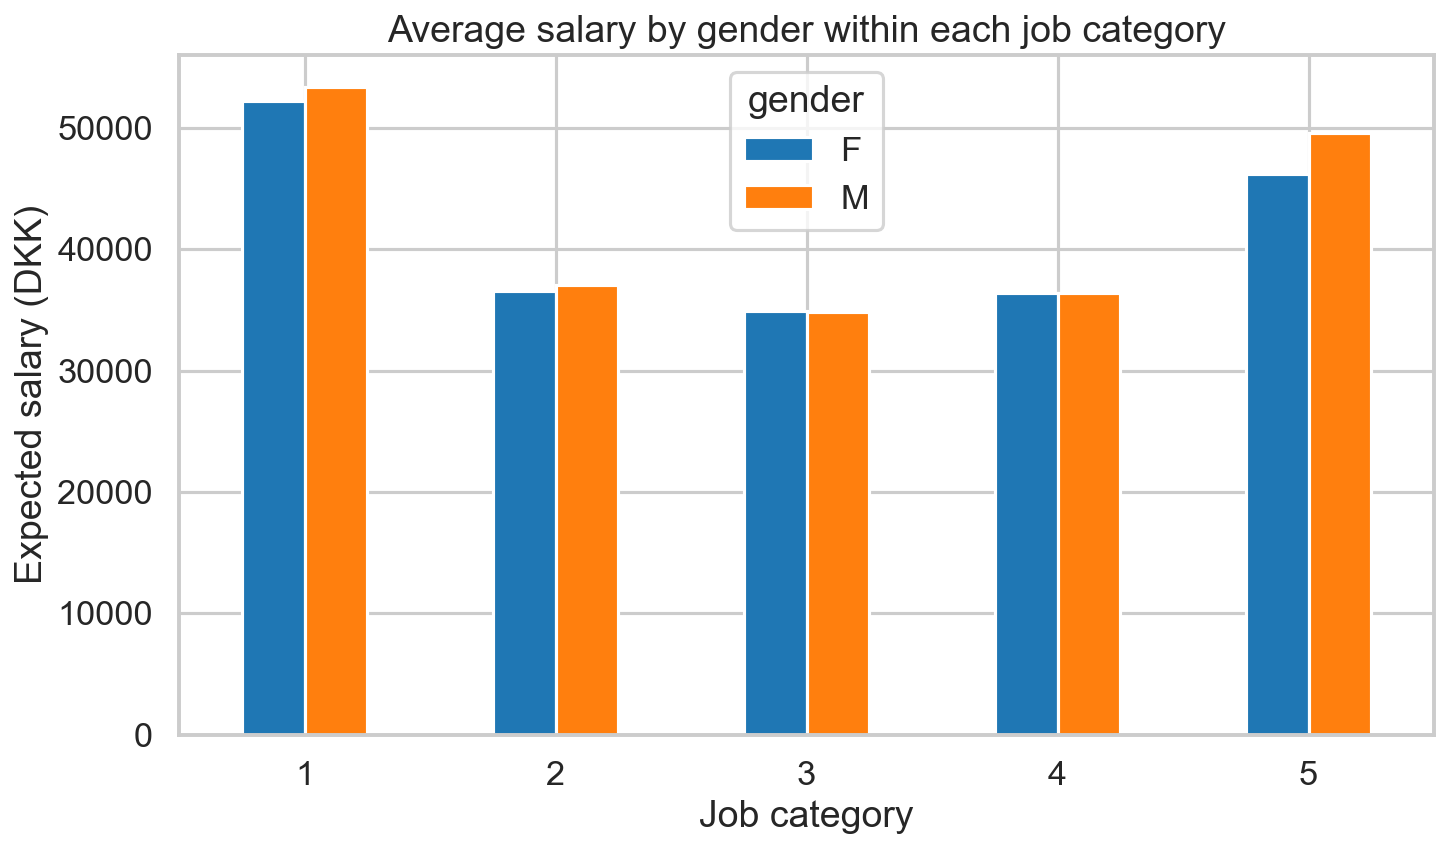

In [2]:
# job_gender_ancova_en.py  ---------------------------------------------
# Checks:
#   1) Do the five job categories differ in pay level?
#   2) Does the gender gap vary from job to job?
# Includes residual-normality diagnostics.
# ---------------------------------------------------------------------
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import numpy as np

CSV = "/Users/vitusthaulow/Documents/GitHub/Project-in-Stat.-Eval.-02445/salaries_3000.csv"

# ---------- 1. Load & prepare ----------------------------------------
cols = ["gender", "age", "occupation", "middle_salary"]
df   = pd.read_csv(CSV, usecols=cols)

for col in ["gender", "age", "occupation"]:
    df[col] = df[col].astype("category")

# ---------- 2. Two-way ANOVA (occupation × gender, controlling age) ---
model = smf.ols("middle_salary ~ C(occupation)*C(gender)+(age)", data=df).fit()
anova = sm.stats.anova_lm(model, typ=2)

print("\n=== 2-way ANOVA + age covariate ===")
print(anova.loc[["C(occupation)", "C(gender)", "C(occupation):C(gender)"]])

# ---------- 3. Residual normality diagnostics ------------------------
resid   = model.resid
resid_z = (resid - resid.mean()) / resid.std(ddof=1)   # standardised residuals

# Shapiro–Wilk (optional but quick to add)
w, p = st.shapiro(resid)
print(f"\nShapiro–Wilk test: W = {w:.3f},  p = {p:.4g}")

# Q–Q plot
sm.qqplot(resid_z, line="45")
plt.title("Q–Q plot of standardised residuals")
plt.tight_layout()
plt.show()

# Histogram
plt.hist(resid_z, bins="auto", edgecolor="k")
plt.xlabel("Standardised residual")
plt.ylabel("Frequency")
plt.title("Histogram of residuals")
plt.tight_layout()
plt.show()

# ---------- 4. Bar-plot (same look-and-feel) --------------------------
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 150

colour_map = {"F": "#1f77b4", "M": "#ff7f0e"}   # blue / orange

mean_tbl = (df.groupby(["occupation", "gender"])["middle_salary"]
              .mean()
              .unstack())

ax = mean_tbl.loc[:, ["F", "M"]].plot(
        kind="bar", figsize=(10, 6), rot=0,
        color=[colour_map["F"], colour_map["M"]])

ax.set_xlabel("Job category")
ax.set_ylabel("Expected salary (DKK)")
ax.set_title("Average salary by gender within each job category")
ax.legend(title="gender")

plt.tight_layout()
plt.show()

In [3]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ------------------------------------------------------------
# 1) Restricted model  (parallel age slope)
#    same formula you used for the main ANCOVA
# ------------------------------------------------------------
m_restricted = smf.ols(
    "middle_salary ~ C(occupation)*C(gender) + age",
    data=df
).fit()

# ------------------------------------------------------------
# 2) Unrestricted model  (age slope allowed to differ)
#    add both interaction terms with age
# ------------------------------------------------------------
m_unrestricted = smf.ols(
    "middle_salary ~ C(occupation)*C(gender) "
    "+ age*C(occupation) + age*C(gender)",
    data=df
).fit()

# ------------------------------------------------------------
# 3) Nested F-test:  H0 = parallel age slopes
# ------------------------------------------------------------
F_stat, p_val, df_diff = m_unrestricted.compare_f_test(m_restricted)

print(f"Parallel-slope test: F = {F_stat:0.2f} "
      f"on {df_diff:.0f} df, p = {p_val:.3g}")

Parallel-slope test: F = 42.00 on 200 df, p = 0


In [4]:
import numpy as np

y = df["middle_salary"].to_numpy(float)
sigma = y.std(ddof=1)
rho3  = np.mean(np.abs(y - y.mean())**3)

BE_C = 0.4748  # best-known Berry–Esseen constant
for eps in (0.05, 0.02, 0.01):        # choose your own tolerances
    n_needed = ((BE_C * rho3) / (sigma**3 * eps))**2
    print(f"ε = {eps:4.2f}  →  n ≥ {np.ceil(n_needed):.0f}")

ε = 0.05  →  n ≥ 151
ε = 0.02  →  n ≥ 943
ε = 0.01  →  n ≥ 3770


In [5]:
rob = model.get_robustcov_results(cov_type="HC3")
print("\n=== HC3 robust summary (key lines) ===")
print(rob.summary().tables[0])         # header with F, p


=== HC3 robust summary (key lines) ===
                            OLS Regression Results                            
Dep. Variable:          middle_salary   R-squared:                       0.925
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                     1088.
Date:                Tue, 17 Jun 2025   Prob (F-statistic):               0.00
Time:                        15:44:40   Log-Likelihood:                -27355.
No. Observations:                3000   AIC:                         5.481e+04
Df Residuals:                    2950   BIC:                         5.511e+04
Df Model:                          49                                         
Covariance Type:                  HC3                                         


In [6]:
# ------------------------------------------------------------
# 1. Brown–Forsythe test (heteroskedasticity)
# ------------------------------------------------------------
from scipy.stats import levene

# split the response by occupation × gender cells
groups = [
    g["middle_salary"].values
    for _, g in df.groupby(["occupation", "gender"], observed=True)
]

W_bf, p_bf = levene(*groups, center="median")
print(f"Brown–Forsythe W = {W_bf:.2f}, p = {p_bf:.3g}")

# ------------------------------------------------------------
# 2. HC3-robust overall F-statistic for the ANCOVA model
# ------------------------------------------------------------
import statsmodels.formula.api as smf

formula = "middle_salary ~ C(occupation)*C(gender) + C(age)"
model   = smf.ols(formula, data=df).fit()
robust  = model.get_robustcov_results(cov_type="HC3")

F_overall   = robust.fvalue
df_model    = int(robust.df_model)
df_resid    = int(robust.df_resid)
p_overall   = robust.f_pvalue

print(f"HC3 overall F = {F_overall:.1f} on {df_model},{df_resid} df, p = {p_overall:.3g}")

Brown–Forsythe W = 96.18, p = 4.96e-158
HC3 overall F = 1087.9 on 49,2950 df, p = 0


In [7]:
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
from packaging import version

# ---------- 1.  Fit model ----------
formula = "middle_salary ~ C(occupation)*C(gender) + age"
model   = smf.ols(formula, data=df).fit()

# ---------- 2.  Type-II SS → partial η² ----------
anova_typ2 = sm.stats.anova_lm(model, typ=2)
ss_resid   = anova_typ2.loc["Residual", "sum_sq"]
anova_typ2 = anova_typ2.drop("Residual")
anova_typ2["partial_eta2"] = (
    anova_typ2["sum_sq"] / (anova_typ2["sum_sq"] + ss_resid)
)

# ---------- 3.  Robust HC-3 F and p ----------
if version.parse(sm.__version__) >= version.parse("0.14"):
    anova_hc3 = sm.stats.anova_lm(model, typ=2, robust="hc3").drop("Residual")
    
    # detect the correct p-value column name
    pcol = "Pr(>F)" if "Pr(>F)" in anova_hc3.columns else "PR(>F)"
    
    anova_typ2["F_HC3"] = anova_hc3["F"]
    anova_typ2["p_HC3"] = anova_hc3[pcol]
else:
    # ---- manual Wald tests for very old versions ----
    robust = model.get_robustcov_results(cov_type="HC3")
    term_map = {
        "C(occupation)": "C(occupation)",
        "C(gender)"    : "C(gender)",
        "C(occupation):C(gender)" : "C(occupation):C(gender)"
    }
    for term in term_map:
        idx = [i for i, n in enumerate(model.model.exog_names)
               if n.startswith(term)]
        R   = np.eye(len(model.params))[idx]
        w   = robust.wald_test(R, use_f=True)
        anova_typ2.loc[term, "F_HC3"] = float(w.statistic)
        anova_typ2.loc[term, "p_HC3"] = float(w.pvalue)

# ---------- 4.  Compact table ----------
compact = anova_typ2[["df", "F_HC3", "p_HC3", "partial_eta2"]]
print(compact.round(3))


                           df     F_HC3  p_HC3  partial_eta2
C(occupation)             4.0  8274.326    0.0         0.913
C(gender)                 1.0    97.133    0.0         0.057
age                      40.0    80.718    0.0         0.605
C(occupation):C(gender)   4.0    38.219    0.0         0.078


In [8]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# --------------------------------------------------
# 1.  Restricted ANCOVA: common age slope
# --------------------------------------------------
mod_restricted = smf.ols(
    "middle_salary ~ C(occupation)*C(gender) + age",
    data=df
).fit()

# --------------------------------------------------
# 2.  Unrestricted model: age slope allowed to vary
#     by occupation and by gender
# --------------------------------------------------
mod_full = smf.ols(
    "middle_salary ~ C(occupation)*C(gender) "
    "+ age*C(occupation) + age*C(gender)",
    data=df
).fit()

# --------------------------------------------------
# 3.  Global parallel-slopes test
# --------------------------------------------------
F_stat, p_val, df_diff = mod_full.compare_f_test(mod_restricted)
print(f"Parallel-slopes test: F = {F_stat:.2f} on {df_diff:.0f} df, p = {p_val:.3g}")

# --------------------------------------------------
# 4.  (Optional) term-wise Wald tests
# --------------------------------------------------
term_tests = mod_full.wald_test_terms(skip_single=False).summary_frame()
print(term_tests.loc[["age:C(occupation)", "age:C(gender)"]])

Parallel-slopes test: F = 42.00 on 200 df, p = 0
                                       F                  P>F  df constraint  \
age:C(occupation)  [[50.45127460043071]]                  0.0            160   
age:C(gender)      [[3.879475741212093]]  5.8506648407175e-15             40   

                   df denom  
age:C(occupation)    2750.0  
age:C(gender)        2750.0  


/usr/local/Caskroom/miniconda/base/lib/python3.11/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
